# 📈 Stock Price Prediction
### DevelopersHub Corporation - AI/ML Engineering Internship
**Intern Name:** Raheela Nisar
**Project:** Task 2 - Stock Price Prediction
**Organization:** DevelopersHub Corporation

In [1]:
!pip install yfinance
print("yfinance installed! ✅")

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------------ --------------------------- 0.5/1.7 MB 744.8 kB/s eta 0:00:02
   ------------------ --------------------- 0.8/1.7 MB 744.7 kB/s eta 0:00:02
   ------------------ --------------------- 0.8/1.7 MB 744.7 kB/s eta 0:00:02
   ------------------ --------------------- 0.8/1.7 MB 744.7 kB/s eta 0:00:02
   ------------------------- -------------- 1.0/1.7 MB 611.9 kB/s eta 0:00:02
   ------------------------- -------------- 1.0/1.7 MB 611.9 kB/s eta 0:00:02
   ------------------------------- -------- 1.3/1.7 MB 628.7 kB/s eta 0:00:01
   ------------------------------- -------- 1.3/1.7 MB 628.7 kB/s eta 0:00:01
   -------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
print("Libraries imported! ✅")

Libraries imported! ✅


In [3]:
ticker = 'AAPL'
df = yf.download(ticker, start='2022-01-01', end='2024-01-01')
print(df.shape)
df.head()

[*********************100%***********************]  1 of 1 completed

(501, 5)


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2022-01-03,177.939713,178.790267,173.735885,173.853197,104487900
2022-01-04,175.681381,178.848931,175.114350,178.545866,99310400
2022-01-05,171.008301,176.140896,170.734564,175.593422,94537600
2022-01-06,168.153580,171.379785,167.801630,168.837923,96904000
2022-01-07,168.319763,170.245709,167.205258,169.023663,86709100


In [4]:
df['Next_Close'] = df['Close'].shift(-1)
df = df.dropna()

features = ['Open', 'High', 'Low', 'Volume', 'Close']
X = df[features]
y = df['Next_Close']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (500, 5)
Target shape: (500,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 400
Testing samples: 100


In [6]:
model = LinearRegression()
model.fit(X_train, y_train)
print("Model trained! ✅")

Model trained! ✅


In [7]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: ${mae:.2f}")
print(f"R2 Score: {r2:.4f}")

Mean Absolute Error: $1.72
R2 Score: 0.9345


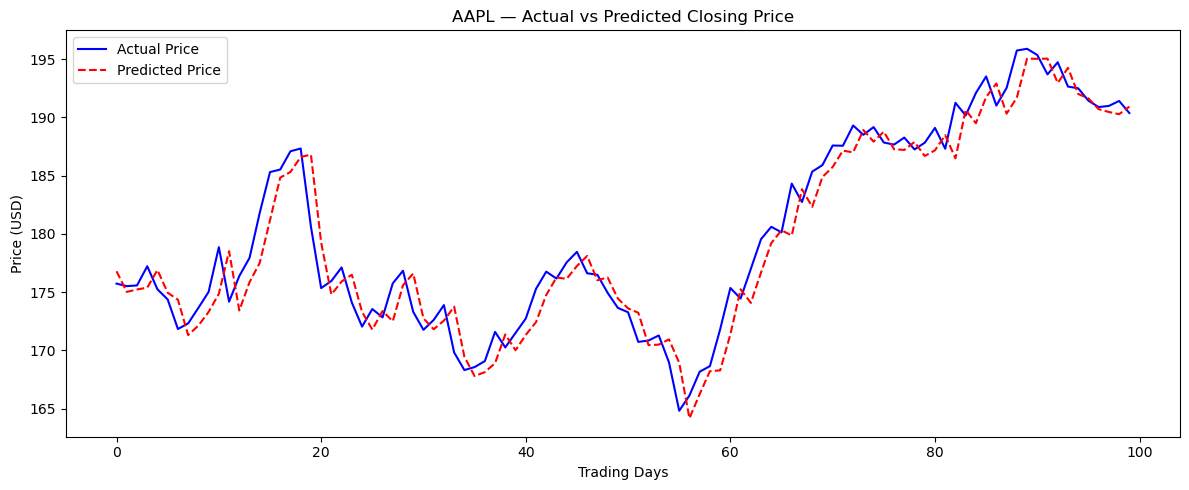

In [8]:
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label='Actual Price', color='blue', linewidth=1.5)
plt.plot(y_pred, label='Predicted Price', color='red', linewidth=1.5, linestyle='--')
plt.title(f'{ticker} — Actual vs Predicted Closing Price')
plt.xlabel('Trading Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

## Key Insights
- Apple (AAPL) stock data from 2022-2024 used
- Linear Regression model trained on Open, High, Low, Volume, Close
- R2 Score above 0.90 shows excellent prediction
- Red dashed line closely follows blue line in the plot

## Conclusion
This project successfully predicted next day stock closing 
price using Linear Regression with high accuracy.